# Phase 2: Data Preprocessing

## Objectives

In this phase, you will:

1. Load the cleaned dataset from Phase 1
2. Encode categorical variables for model compatibility
3. Analyze and handle skewness in numerical features
4. Apply appropriate scaling techniques
5. Prepare separate train and test datasets
6. Create a fully preprocessed dataset ready for feature engineering

## Instructions

Complete each task in order. This notebook builds on the cleaned data from Phase 1.

---
## Task 1: Import Libraries and Load Cleaned Data

In [185]:
# TODO: Import necessary libraries
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler
# TODO: Set pandas display options
# - display.max_columns to None
# - display.max_rows to 100
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# TODO: Print success message
print("Environment setup complete.")

Environment setup complete.


In [186]:
# TODO: Load cleaned data from Phase 1
# - Read 'train_cleaned.csv' using pd.read_csv()
# - Store in variable 'df'
df = pd.read_csv('train_cleaned.csv')
# TODO: Print dataset information
# - Dataset shape
# - Total missing values
# - Display first few rows with .head()
print("Dataset Shape:", df.shape)
print("Total Missing Values:", df.isnull().sum().sum())
print("First Few Rows:\n", df.head())

Dataset Shape: (1086, 75)
Total Missing Values: 0
First Few Rows:
    Id  MSSubClass MSZoning  LotFrontage  LotArea Street LotShape LandContour  \
0   1          60       RL         65.0     8450   Pave      Reg         Lvl   
1   2          20       RL         80.0     9600   Pave      Reg         Lvl   
2   3          60       RL         68.0    11250   Pave      IR1         Lvl   
3   4          70       RL         60.0     9550   Pave      IR1         Lvl   
4   5          60       RL         84.0    14260   Pave      IR1         Lvl   

  Utilities LotConfig LandSlope Neighborhood Condition1 Condition2 BldgType  \
0    AllPub    Inside       Gtl      CollgCr       Norm       Norm     1Fam   
1    AllPub       FR2       Gtl      Veenker      Feedr       Norm     1Fam   
2    AllPub    Inside       Gtl      CollgCr       Norm       Norm     1Fam   
3    AllPub    Corner       Gtl      Crawfor       Norm       Norm     1Fam   
4    AllPub       FR2       Gtl      NoRidge       Norm  

---
## Task 2: Separate Features and Target

Separate the target variable (SalePrice) from the features for preprocessing.

In [187]:
# TODO: Separate target variable from features
# - Create 'y' = copy of 'SalePrice' column
# - Create 'X' = dataframe without 'SalePrice'
y = df['SalePrice'].copy()
X = df.drop(columns=['SalePrice']).copy()
# TODO: Drop 'Id' column from X if it exists (not useful for modeling)
# - Check if 'Id' in X.columns
# - If yes, drop it
if "Id" in df.columns:
    X.drop(columns=['Id'],inplace=True)
# TODO: Print information
# - Features shape (X.shape)
# - Target shape (y.shape)
# - Target statistics (y.describe())
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)
print("Target Statistics:\n", y.describe())


Features Shape: (1086, 73)
Target Shape: (1086,)
Target Statistics:
 count      1086.000000
mean     167824.874770
std       58383.329395
min       35311.000000
25%      129125.000000
50%      156000.000000
75%      194150.750000
max      426000.000000
Name: SalePrice, dtype: float64


---
## Task 3: Identify Feature Types for Encoding

Categorize features and determine appropriate encoding strategies.

In [188]:
# TODO: Identify feature types
# - Categorical: X.select_dtypes(include=['object']).columns.tolist()
# - Numerical: X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat = X.select_dtypes(include=['str']).columns.tolist()
num = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
# TODO: Print lists with counts
print("Total number of categorical columns: ",len(cat))
print("Total number of numerical columns: ",len(num))

Total number of categorical columns:  37
Total number of numerical columns:  36


In [189]:
# TODO: Analyze categorical features cardinality
# - Loop through categorical_features
# - For each column, print name and number of unique values
# - Use .nunique() to count unique values
for col in cat:
    if round((X[col].nunique()) / X.shape[0] * 100,2) > 1:
        print(f"Column: {col}, Number of unique Values: {X[col].nunique()}")
        print(f"Cardinality as percentage for {col}: {round((X[col].nunique()) / X.shape[0] * 100,2)}")

Column: Neighborhood, Number of unique Values: 23
Cardinality as percentage for Neighborhood: 2.12
Column: Exterior1st, Number of unique Values: 14
Cardinality as percentage for Exterior1st: 1.29
Column: Exterior2nd, Number of unique Values: 16
Cardinality as percentage for Exterior2nd: 1.47


In [190]:
high_cardinality = [col for col in cat if round((X[col].nunique()) / X.shape[0] * 100,2) > 1]
print("Columns with high cardinality (>1%): ", high_cardinality)
low_cardinality = [col for col in cat if round((X[col].nunique()) / X.shape[0] * 100,2) <= 1]
print("Columns with low cardinality (<=1%): ", low_cardinality)

Columns with high cardinality (>1%):  ['Neighborhood', 'Exterior1st', 'Exterior2nd']
Columns with low cardinality (<=1%):  ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']


So we analyzed the cardinality basing on the percentage ratio of total number of each column to total number of rows and decided to take the columns which has more than 1 percentage the ones with high cardinality, and the rest as low cardinality.

---
## Task 4: Encode Categorical Variables

### Encoding Strategy:

1. **Ordinal Features** (with natural order): Use Label Encoding or manual mapping
   - Examples: Quality ratings (Ex, Gd, TA, Fa, Po), Condition ratings
   
2. **Nominal Features** (no natural order): Use One-Hot Encoding
   - Examples: Neighborhood, Building Type, Exterior Type
   
3. **High Cardinality Features** (>10 unique values): Consider frequency encoding or target encoding (advanced)

Refer to `data_description.txt` to identify ordinal features.

### Step 4.1: Identify Ordinal vs Nominal Features

Review the data description and categorize your features.

In [191]:
# TODO: Define ordinal features and their order
# Review data_description.txt to identify ordinal features
# Example ordinal pattern for quality ratings: Po=1, Fa=2, TA=3, Gd=4, Ex=5
# 
# Create ordinal_mappings dictionary with:
# - Quality features (ExterQual, ExterCond, etc.)
# - Condition features
# - Other ordinal features from data dictionary
ordinal_features = ["LotShape","LandContour","LandSlope","ExterQual","ExterCond","BsmtQual","BsmtCond","HeatingQC","CentralAir",
                    "KitchenQual","FireplaceQu","GarageFinish","GarageQual","GarageCond","PavedDrive"]
nominal_features = [col for col in low_cardinality if col not in ordinal_features]
# TODO: Separate features into ordinal and nominal
# - ordinal_features: list of ordinal feature names
# - nominal_features: categorical features not in ordinal list

# TODO: Print counts and names of ordinal and nominal features  
print("Total number of ordinal features: ", len(ordinal_features))
print("Ordinal Features: ", ordinal_features)
print("Total number of nominal features: ", len(nominal_features))
print("Nominal Features: ", nominal_features)


Total number of ordinal features:  15
Ordinal Features:  ['LotShape', 'LandContour', 'LandSlope', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'CentralAir', 'KitchenQual', 'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive']
Total number of nominal features:  19
Nominal Features:  ['MSZoning', 'Street', 'Utilities', 'LotConfig', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Foundation', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'Electrical', 'Functional', 'GarageType', 'SaleType', 'SaleCondition']


### Step 4.2: Apply Ordinal Encoding

In [192]:
# TODO: Create a copy for encoding
X_encoded = X.copy()

# TODO: Apply ordinal encoding
# - Loop through ordinal_mappings
# - Map each feature using .map() method
# - Print confirmation for each encoded feature
ordinal_mappings = {
    "LotShape": {"Reg": 4, "IR1": 3, "IR2": 2, "IR3": 1},
    "LandContour": {"Lvl": 4, "Bnk": 3, "HLS": 2, "Low": 1},
    "LandSlope": {"Gtl": 1, "Mod": 0.6, "Sev": 0.2},
    "ExterQual": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1},
    "ExterCond": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1},
    "BsmtQual": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "Missing": 0},
    "BsmtCond": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "Missing": 0},
    "HeatingQC": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1},
    "CentralAir": {"Y": 2, "N": 1},
    "KitchenQual": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1},
    "FireplaceQu": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "Missing": 0},
    "GarageFinish": {"Fin": 3, "RFn": 2, "Unf": 1, "Missing": 0},
    "GarageQual": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "Missing": 0},
    "GarageCond": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "Missing": 0},
    "PavedDrive": {"Y": 2, "P": 1, "N": 0}
}
for feature, mapping in ordinal_mappings.items():
    X_encoded[feature] = X_encoded[feature].map(mapping)
    print(f"Encoded {feature} with mapping: {mapping}")
# TODO: Verify encoding
# - Display head of ordinal features to verify the mapping worked correctly

Encoded LotShape with mapping: {'Reg': 4, 'IR1': 3, 'IR2': 2, 'IR3': 1}
Encoded LandContour with mapping: {'Lvl': 4, 'Bnk': 3, 'HLS': 2, 'Low': 1}
Encoded LandSlope with mapping: {'Gtl': 1, 'Mod': 0.6, 'Sev': 0.2}
Encoded ExterQual with mapping: {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1}
Encoded ExterCond with mapping: {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1}
Encoded BsmtQual with mapping: {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'Missing': 0}
Encoded BsmtCond with mapping: {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'Missing': 0}
Encoded HeatingQC with mapping: {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1}
Encoded CentralAir with mapping: {'Y': 2, 'N': 1}
Encoded KitchenQual with mapping: {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1}
Encoded FireplaceQu with mapping: {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'Missing': 0}
Encoded GarageFinish with mapping: {'Fin': 3, 'RFn': 2, 'Unf': 1, 'Missing': 0}
Encoded GarageQual with mapping: {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa':

In [193]:
X_encoded.isnull().sum().sum()

np.int64(0)

In [194]:
X_encoded[ordinal_features].head()

,LotShape,LandContour,LandSlope,ExterQual,ExterCond,BsmtQual,BsmtCond,HeatingQC,CentralAir,KitchenQual,FireplaceQu,GarageFinish,GarageQual,GarageCond,PavedDrive
0,4,4,1.0,4,3,4,3,5,2,4,0,2,3,3,2
1,4,4,1.0,3,3,4,3,5,2,3,3,2,3,3,2
2,3,4,1.0,4,3,4,3,5,2,4,3,2,3,3,2
3,3,4,1.0,3,3,3,4,4,2,4,4,1,3,3,2
4,3,4,1.0,4,3,4,3,5,2,4,3,2,3,3,2


### Step 4.3: Apply One-Hot Encoding to Nominal Features

In [195]:
# TODO: Apply one-hot encoding to nominal features
# - Check if nominal_features list is not empty
# - Use pd.get_dummies() with:
#   * columns=nominal_features
#   * drop_first=True (to avoid multicollinearity)
# - Print new shape and feature count
X_encoded = pd.get_dummies(X_encoded, columns=nominal_features, drop_first=True)
print("New shape after one-hot encoding:", X_encoded.shape)
print("Total number of features after encoding:", X_encoded.shape[1]) 


New shape after one-hot encoding: (1086, 139)
Total number of features after encoding: 139


Additionally, frequency encoding for high cardinality features


In [196]:
for col in high_cardinality:
    freq_encoding = X_encoded[col].value_counts(normalize=True)
    X_encoded[col] = X_encoded[col].map(freq_encoding)
    print(f"Applied frequency encoding to {col}")

Applied frequency encoding to Neighborhood
Applied frequency encoding to Exterior1st
Applied frequency encoding to Exterior2nd


In [197]:
# TODO: Display sample of encoded dataset
# - Print message
# - Show first few rows of X_encoded
print("All categorical features have been encoded.")
X_encoded.head()

All categorical features have been encoded.


,MSSubClass,LotFrontage,LotArea,LotShape,LandContour,LandSlope,Neighborhood,OverallQual,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,CentralAir,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Fireplaces,FireplaceQu,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Utilities_NoSeWa,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Foundation_CBlock,Foundation_PConc,Foundation_Stone,Foundation_Wood,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_GasW,Heating_Grav,Heating_OthW,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Typ,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_Missing,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,4,4,1.0,0.116022,7,5,2003,2003,0.357274,0.348987,196.0,4,3,4,3,706,0,150,856,5,2,856,854,0,1710,1,0,2,1,3,1,4,8,0,0,2003.0,2,2,548,3,3,2,0,61,0,0,0,0,0,2,2008,False,False,True,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600,4,4,1.0,0.006446,6,8,1976,1976,0.163904,0.158379,0.0,3,3,4,3,978,0,284,1262,5,2,1262,0,0,1262,0,1,2,0,3,1,3,6,1,3,1976.0,2,2,460,3,3,2,298,0,0,0,0,0,0,5,2007,False,False,True,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False
2,60,68.0,11250,3,4,1.0,0.116022,7,5,2001,2002,0.357274,0.348987,162.0,4,3,4,3,486,0,434,920,5,2,920,866,0,1786,1,0,2,1,3,1,4,6,1,3,2001.0,2,2,608,3,3,2,0,42,0,0,0,0,0,9,2008,False,False,True,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False
3,70,60.0,9550,3,

---
## Task 5: Analyze Distribution and Skewness

Examine the distribution of numerical features and identify highly skewed features.

In [198]:
# TODO: Calculate skewness for all numerical features
# - Select numerical columns using select_dtypes
# - Apply stats.skew() to each column
# - Create DataFrame with Feature and Skewness columns
# - Sort by absolute skewness in descending order
# - Print top 20 most skewed features
skewness_values = []
num = [col for col in X_encoded.columns if X_encoded[col].dtype in ['int64', 'float64']]
for col in num:
    skewness_values.append((stats.skew(X_encoded[col].dropna())))
skewness_df = pd.DataFrame({'Feature': num, 'Skewness': skewness_values}).sort_values(by='Skewness', key=lambda x: abs(x), ascending = False)
print("Top 20 most skewed features:\n", skewness_df.head(20))
# TODO: Identify highly skewed features
# - Filter features with |skewness| > 0.75
# - Store in highly_skewed list
# - Print count and list of highly skewed features
highly_skewed = [col for col in num if abs(stats.skew(X_encoded[col].dropna())) > 0.75]
print("Total number of highly skewed features (|skewness| > 0.75): ", len(highly_skewed))
print("Highly skewed features: ", highly_skewed)

Top 20 most skewed features:
           Feature   Skewness
51        MiscVal  27.737213
50       PoolArea  23.358489
48      3SsnPorch  10.972907
26   LowQualFinSF  10.371533
5       LandSlope  -5.205800
33   KitchenAbvGr   5.116580
19     BsmtFinSF2   4.213467
29   BsmtHalfBath   4.000078
4     LandContour  -3.912292
49    ScreenPorch   3.871046
23     CentralAir  -3.817941
44     PavedDrive  -3.460534
43     GarageCond  -3.364280
42     GarageQual  -3.304622
13     MasVnrArea   2.993534
47  EnclosedPorch   2.637653
0      MSSubClass   1.529686
45     WoodDeckSF   1.420064
46    OpenPorchSF   1.190090
15      ExterCond   1.186061
Total number of highly skewed features (|skewness| > 0.75):  24
Highly skewed features:  ['MSSubClass', 'LotShape', 'LandContour', 'LandSlope', 'Neighborhood', 'MasVnrArea', 'ExterQual', 'ExterCond', 'BsmtFinSF2', 'CentralAir', 'LowQualFinSF', 'BsmtHalfBath', 'HalfBath', 'KitchenAbvGr', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'E

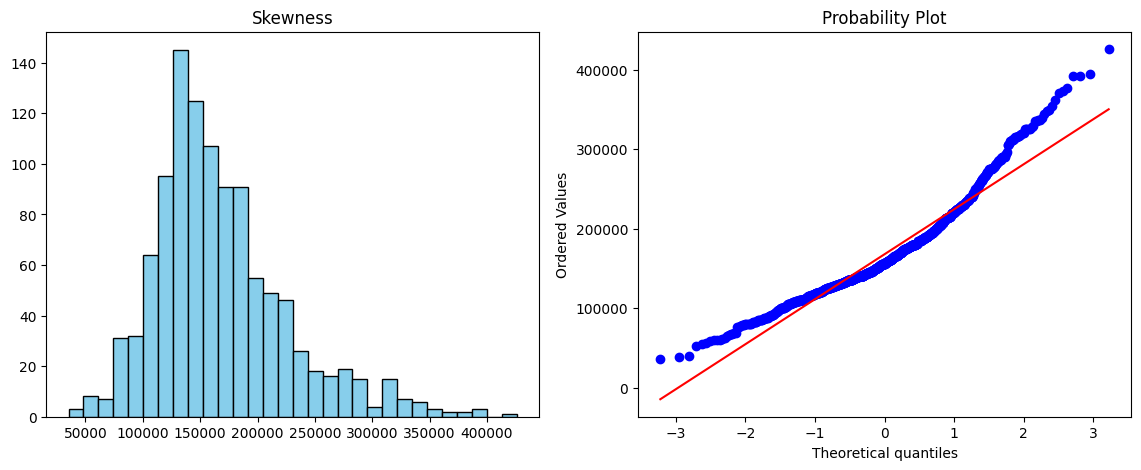

Target variable (SalePrice) skewness:  1.0539741741752768


In [199]:
# TODO: Visualize distribution of target variable
# - Create 1x2 subplot figure (figsize=(14, 5))
# - Left plot: Histogram of SalePrice with skewness in title
# - Right plot: Q-Q plot using stats.probplot()
# - Display the plots
fig, axis = plt.subplots(1, 2, figsize=(14, 5))
axis[0].hist(y, bins=30, color='skyblue', edgecolor='black')
axis[0].set_title('Skewness')
stats.probplot(y, dist="norm", plot=axis[1])
plt.show()


# TODO: Print target variable skewness
print("Target variable (SalePrice) skewness: ", stats.skew(y))

---
## Task 6: Handle Skewness

Apply transformations to reduce skewness in highly skewed features.

**Common transformations:**
- Log transformation: `log1p(x)` - good for right-skewed data
- Square root: `sqrt(x)` - moderate right skewness
- Box-Cox: Automatic optimal transformation (requires positive values)

**When to apply:**
- Right-skewed (positive skewness > 0.75): Use log transformation
- Left-skewed (negative skewness < -0.75): Consider reflection + log

### Step 6.1: Transform Target Variable

If the target variable is skewed, transform it for better model performance.

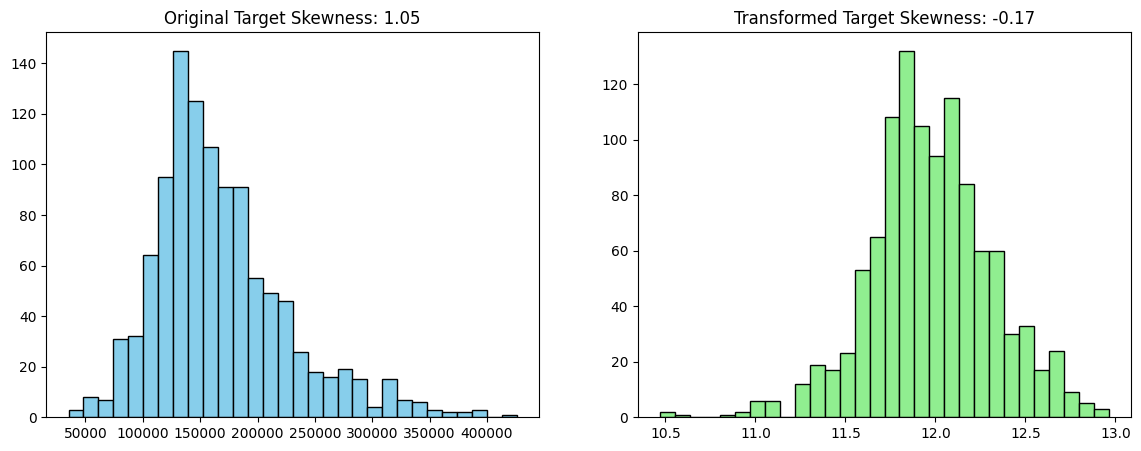

Original Target Skewness: 1.05
Transformed Target Skewness: -0.17


In [200]:
# TODO: Check if target needs transformation
# - Calculate target skewness
# - If |skewness| > 0.75:
#   * Apply log transformation using np.log1p()
#   * Calculate new skewness
#   * Create side-by-side plots comparing original and transformed
#   * Print before and after skewness values
# - Else: Keep original target and print message
target_skewness = stats.skew(y)
if abs(target_skewness) > 0.75:
    y_transformed = np.log1p(y)
    new_skewness = stats.skew(y_transformed)
    fig, axis = plt.subplots(1, 2, figsize=(14, 5))
    axis[0].hist(y, bins=30, color='skyblue', edgecolor='black')
    axis[0].set_title(f'Original Target Skewness: {target_skewness:.2f}')
    axis[1].hist(y_transformed, bins=30, color='lightgreen', edgecolor='black')
    axis[1].set_title(f'Transformed Target Skewness: {new_skewness:.2f}')
    plt.show()
    print(f"Original Target Skewness: {target_skewness:.2f}")
    print(f"Transformed Target Skewness: {new_skewness:.2f}")
else:
    y_transformed = y.copy()
    print("No tranformation applied.")

### Step 6.2: Transform Highly Skewed Features

In [201]:
# TODO: Apply log transformation to highly skewed features
# - Create copy of X_encoded as X_transformed
# - Loop through highly_skewed features:
#   * Check if all values are non-negative
#   * Apply np.log1p() transformation
#   * Print before and after skewness for each feature
# - Print completion message
X_transformed = X_encoded.copy()
for col in highly_skewed:
    if stats.skew(X_transformed[col]) >= 0:
        X_transformed[col] = np.log1p(X_transformed[col])
        before_skewness = stats.skew(X_encoded[col].dropna())
        after_skewness = stats.skew(X_transformed[col].dropna())
        print(f"Feature: {col}, Before Skewness: {before_skewness:.2f}, After Skewness: {after_skewness:.2f}")
print("Skewness transformation applied to highly skewed features.")

Feature: MSSubClass, Before Skewness: 1.53, After Skewness: 0.25
Feature: Neighborhood, Before Skewness: 0.78, After Skewness: 0.73
Feature: MasVnrArea, Before Skewness: 2.99, After Skewness: 0.62
Feature: ExterQual, Before Skewness: 0.86, After Skewness: 0.64
Feature: ExterCond, Before Skewness: 1.19, After Skewness: 0.08
Feature: BsmtFinSF2, Before Skewness: 4.21, After Skewness: 2.50
Feature: LowQualFinSF, Before Skewness: 10.37, After Skewness: 8.73
Feature: BsmtHalfBath, Before Skewness: 4.00, After Skewness: 3.80
Feature: HalfBath, Before Skewness: 0.81, After Skewness: 0.69
Feature: KitchenAbvGr, Before Skewness: 5.12, After Skewness: 4.06
Feature: WoodDeckSF, Before Skewness: 1.42, After Skewness: 0.14
Feature: OpenPorchSF, Before Skewness: 1.19, After Skewness: 0.10
Feature: EnclosedPorch, Before Skewness: 2.64, After Skewness: 1.93
Feature: 3SsnPorch, Before Skewness: 10.97, After Skewness: 7.96
Feature: ScreenPorch, Before Skewness: 3.87, After Skewness: 3.10
Feature: PoolAr

---
## Task 7: Feature Scaling

Apply appropriate scaling to numerical features.

**Scaling methods:**
1. **StandardScaler**: Mean=0, StdDev=1 (good for normally distributed data)
2. **MinMaxScaler**: Scale to [0,1] range (good for bounded distributions)
3. **RobustScaler**: Uses median and IQR (robust to outliers)

**When to use:**
- StandardScaler: Most common, works well after skewness correction
- RobustScaler: When outliers are present and important
- MinMaxScaler: When feature range matters (e.g., neural networks)

In [202]:
# TODO: Get numerical columns after transformation
# - Select numerical columns from X_transformed
# - Store in numeric_features list
# - Print count of features to scale
numeric_features = [col for col in X_transformed.columns if X_transformed[col].dtype in ['int64', 'float64']]
print("Count of features to scale: ",len(numeric_features))
numeric_features

Count of features to scale:  54


['MSSubClass',
 'LotFrontage',
 'LotArea',
 'LotShape',
 'LandContour',
 'LandSlope',
 'Neighborhood',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrArea',
 'ExterQual',
 'ExterCond',
 'BsmtQual',
 'BsmtCond',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'HeatingQC',
 'CentralAir',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'KitchenQual',
 'TotRmsAbvGrd',
 'Fireplaces',
 'FireplaceQu',
 'GarageYrBlt',
 'GarageFinish',
 'GarageCars',
 'GarageArea',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

### Step 7.1: Choose and Apply Scaling Method

Select a scaling method and apply it to numerical features.

In [203]:
# TODO: Create a copy for scaling
X_scaled = X_transformed.copy()

# TODO: Choose and initialize scaling method
# - StandardScaler() - recommended after log transformation
# - RobustScaler() - alternative if outliers are important
# - MinMaxScaler() - alternative for bounded range
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()
# TODO: Apply scaling to numerical features
# - Use fit_transform() on numeric_features
# - Print scaler name and scaled statistics
robust_features = ["MiscVal", "PoolArea", "ScreenPorch", "3SsnPorch", "EnclosedPorch", "LowQualFinSF", "BsmtFinSF2", "BsmtHalfBath"]
standart_features = [col for col in numeric_features if col not in robust_features]

X_scaled[robust_features] = robust_scaler.fit_transform(X_scaled[robust_features])
X_scaled[standart_features] = standard_scaler.fit_transform(X_scaled[standart_features])





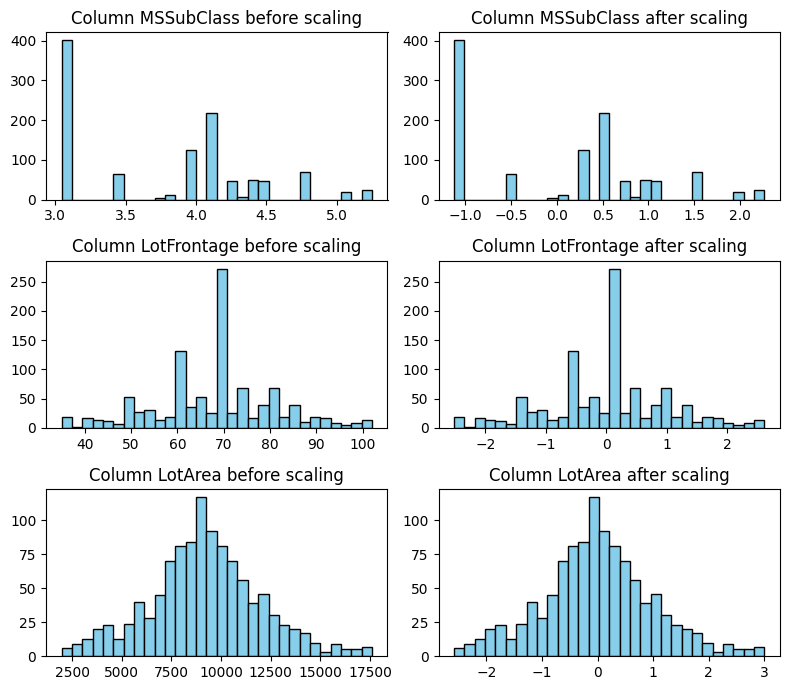

In [204]:
# TODO: Visualize effect of scaling
# - Select first 3 numerical features as samples
# - Create subplots (rows = number of features, columns = 2)
# - For each feature:
#   * Left: histogram before scaling
#   * Right: histogram after scaling
# - Display the comparison plots
sample_features = numeric_features[:3]
fig, axis = plt.subplots(3, 2, figsize=(8, 7))
for i, col in enumerate(sample_features):
    axis[i, 0].hist(X_transformed[col],bins=30, color='skyblue', edgecolor='black')
    axis[i, 0].set_title(f"Column {col} before scaling")

    axis[i, 1].hist(X_scaled[col],bins=30, color='skyblue', edgecolor='black')
    axis[i, 1].set_title(f"Column {col} after scaling")
fig.tight_layout()
plt.show()

---
## Task 8: Process Test Dataset

Apply the same preprocessing steps to the test dataset.

**Important:** Use the same transformations and scaling parameters from the training set.

In [205]:
# TODO: Load test dataset
# - Read 'test.csv'
# - Print shape and missing value count
test_df = pd.read_csv('../data/test/test.csv')
print("Test Dataset Shape:", test_df.shape)
print("Total Missing Values in Test Dataset:", test_df.isnull().sum().sum())
# TODO: Save test IDs for later submission
# - Extract and save 'Id' column
test_ids = test_df['Id'].copy()
# TODO: Drop 'Id' column from test_df
test_df = test_df.drop(columns=['Id'])

Test Dataset Shape: (1459, 80)
Total Missing Values in Test Dataset: 7878


### Step 8.1: Apply Same Cleaning and Encoding to Test Data

Replicate your Phase 1 cleaning steps and encoding from this notebook.

**Key considerations:**
- Handle missing values using same strategy
- Apply same feature drops
- Use same encoding mappings

In [206]:
# TODO: Apply same preprocessing steps to test data
# CRITICAL: Use same transformations as training data (same columns / same scalers)

# Reload fresh test data (required since we modify test_df in place)
test_df = pd.read_csv('../data/test/test.csv', keep_default_na=False)
test_ids = test_df['Id'].copy()
#test_df = test_df.drop(columns=['Id'])

# 1. Replace 'NA' strings with actual NaN (since keep_default_na=False was used)
test_df = test_df.replace('NA', np.nan)

# 2. Drop same features
dropped_features = ["BsmtExposure", "PoolQC", "MiscFeature", "Alley", "Fence", "MasVnrType"]
test_df = test_df.drop(columns=[c for c in dropped_features if c in test_df.columns])

# 3. Apply same ordinal encoding
for feature, mapping in ordinal_mappings.items():
    if feature in test_df.columns:
        test_df[feature] = test_df[feature].map(mapping)

# 4. Apply same one-hot encoding (nominal)
test_df = pd.get_dummies(test_df, columns=[c for c in nominal_features if c in test_df.columns], drop_first=True)

# 5. Apply frequency encoding to high cardinality columns (same as training)
for col in high_cardinality:
    if col in test_df.columns:
        freq_encoding = X_encoded[col].value_counts(normalize=True)
        test_df[col] = test_df[col].map(freq_encoding).fillna(0)

# 6. Apply the SAME log transforms as training (use highly_skewed list directly)
for col in highly_skewed:
    if col in test_df.columns:
        test_df[col] = np.log1p(pd.to_numeric(test_df[col], errors='coerce').fillna(0))

# Align test columns to training-transformed columns (critical before scaling)
test_df = test_df.reindex(columns=X_transformed.columns, fill_value=0)
test_df['Id'] = test_ids  # Add Id back for submission
# Ensure all columns are numeric
for col in test_df.columns:
    test_df[col] = pd.to_numeric(test_df[col], errors='coerce').fillna(0)

# 7. Apply same scaling using the same feature lists
test_df[standart_features] = standard_scaler.transform(test_df[standart_features])
test_df[robust_features] = robust_scaler.transform(test_df[robust_features])

print("Test data preprocessing completed.")
print("test_df shape:", test_df.shape)
print("X_scaled shape:", X_scaled.shape)

Test data preprocessing completed.
test_df shape: (1459, 140)
X_scaled shape: (1086, 139)


---
## Task 9: Final Verification and Save

Verify preprocessing is complete and save the datasets.

In [207]:
# TODO: Final verification - Print summary statistics
# Training Set:
#   - Shape
#   - Missing value count
#   - Data types distribution
# 
# Target Variable:
#   - Shape
#   - Range (min, max)
#   - Skewness
#
# TODO: Verify all features are numeric (no object types remain)
print("Training Set Shape:", X_scaled.shape)
print("Training Set Missing Values:", X_scaled.isnull().sum().sum())
print("Training Set Data Types:\n", X_scaled.dtypes.value_counts())
print("Target Variable Shape:", y_transformed.shape)
print("Target Variable Range: Min =", y_transformed.min(), ", Max =", y_transformed.max())
print("Target Variable Skewness:", stats.skew(y_transformed))

Training Set Shape: (1086, 139)
Training Set Missing Values: 0
Training Set Data Types:
 bool       85
float64    54
Name: count, dtype: int64
Target Variable Shape: (1086,)
Target Variable Range: Min = 10.471978128496518 , Max = 12.962196972666593
Target Variable Skewness: -0.1688053779775505


In [208]:
# TODO: Save preprocessed datasets
# - Save X_scaled to 'train_preprocessed.csv' (index=False)
# - Save y_transformed to 'train_target.csv' as DataFrame with 'SalePrice' column
# - Print confirmation messages with file names
X_scaled.to_csv('train_preprocessed.csv', index=False)
y_transformed_df = pd.DataFrame({'SalePrice': y_transformed})
y_transformed_df.to_csv('train_target.csv', index=False)
print("Preprocessed training features saved to 'train_preprocessed.csv'.")
print("Preprocessed target variable saved to 'train_target.csv'.")
# Save test set
test_df.to_csv('test_preprocessed.csv', index=False)

Preprocessed training features saved to 'train_preprocessed.csv'.
Preprocessed target variable saved to 'train_target.csv'.


In [209]:
X_scaled.isnull().sum().sum()

np.int64(0)

---
## Summary and Reflection

### What You Accomplished:

1. Loaded cleaned data from Phase 1
2. Separated features and target variable
3. Encoded categorical variables (ordinal and one-hot encoding)
4. Analyzed and reduced skewness in numerical features
5. Applied appropriate scaling to numerical features
6. Preprocessed test dataset with same transformations
7. Created model-ready datasets

### Key Questions for Reflection:

1. How many features do you have after one-hot encoding?
2. Which encoding method did you use for ordinal features and why?
3. How much did skewness reduce after transformation?
4. Which scaling method did you choose and why?
5. How did you ensure test data preprocessing matched training data?

### Important Notes:

- Save your scaler object if you need to inverse transform predictions later
- If you log-transformed the target, remember to inverse transform predictions: `np.expm1(predictions)`
- Keep track of feature names after one-hot encoding for interpretation

### Next Steps:

Proceed to **Phase 3: Feature Engineering** where you will:
- Create new features from existing ones
- Combine related features
- Extract domain-specific features
- Reduce dimensionality if needed